## V3 f-AnoGAN

In [3]:
from pathlib import Path
import torch
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from torchvision import transforms
# Change this if your dataset is elsewhere
import zipfile

ZIP_PATH = Path("/content/nssc.zip")
DATA_ROOT = Path("/content/nssc_dataset")

DATA_ROOT.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(DATA_ROOT)

print("Dataset extracted to:", DATA_ROOT)



DATA_ROOT = Path("/content/nssc_dataset/test+train")

TRAIN_NORMAL_DIR = DATA_ROOT / "train" / "normal"
TEST_NORMAL_DIR = DATA_ROOT / "test" / "normal"
TEST_ANOMALY_DIR = DATA_ROOT / "test" / "anomaly_real"

IMAGE_SIZE = 64       # Use 128 or 256 for more detail if GPU memory allows
CHANNELS = 3          # Set to 1 for grayscale images
BATCH_SIZE = 32
NUM_WORKERS = 0       # Keep 0 initially on Windows

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}


# f-AnoGAN generator typically uses Tanh output, so normalize images to [-1, 1].
transform = transforms.Compose([
    transforms.Lambda(
        lambda image: image.convert("L") if CHANNELS == 1 else image.convert("RGB")
    ),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5] * CHANNELS,
        std=[0.5] * CHANNELS,
    ),
])


class AnomalyImageDataset(Dataset):
    """
    Loads images from one folder.

    label:
      0 = normal
      1 = anomaly
    """

    def __init__(self, folder, label=0, transform=None):
        self.folder = Path(folder)
        self.label = label
        self.transform = transform

        self.image_paths = sorted(
            path for path in self.folder.rglob("*")
            if path.suffix.lower() in IMAGE_EXTENSIONS
        )

        if len(self.image_paths) == 0:
            raise RuntimeError(f"No images found in: {self.folder}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image_path = self.image_paths[index]

        with Image.open(image_path) as image:
            image = self.transform(image)

        return image, self.label, str(image_path)


# Training data: all assumed normal, no anomaly labels required.
train_dataset = AnomalyImageDataset(
    folder=TRAIN_NORMAL_DIR,
    label=0,
    transform=transform,
)

# Test data: labels are used later only for evaluation.
test_normal_dataset = AnomalyImageDataset(
    folder=TEST_NORMAL_DIR,
    label=0,
    transform=transform,
)

test_anomaly_dataset = AnomalyImageDataset(
    folder=TEST_ANOMALY_DIR,
    label=1,
    transform=transform,
)

test_dataset = torch.utils.data.ConcatDataset([
    test_normal_dataset,
    test_anomaly_dataset,
])


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)


# Check that data loads correctly
images, labels, paths = next(iter(train_loader))

print("Training images shape:", images.shape)
# Example RGB: torch.Size([32, 3, 64, 64])

print("Training labels:", labels[:5])
print("Example path:", paths[0])

print("Number of train-normal images:", len(train_dataset))
print("Number of test-normal images:", len(test_normal_dataset))
print("Number of test-anomaly images:", len(test_anomaly_dataset))

Dataset extracted to: /content/nssc_dataset
Training images shape: torch.Size([32, 3, 64, 64])
Training labels: tensor([0, 0, 0, 0, 0])
Example path: /content/nssc_dataset/test+train/train/normal/ESP_019559_1390_RED-0407-fv.jpg
Number of train-normal images: 20000
Number of test-normal images: 2100
Number of test-anomaly images: 5125


In [4]:
import torch
import torch.nn as nn


LATENT_DIM = 128
IMAGE_CHANNELS = 3   # Must match CHANNELS from your data-loading code
BASE_CHANNELS = 64   # Increase only if you have enough GPU memory


def weights_init(module):
    """
    Standard DCGAN-style initialization.
    """
    classname = module.__class__.__name__

    if "Conv" in classname:
        nn.init.normal_(module.weight.data, mean=0.0, std=0.02)

    elif "BatchNorm" in classname:
        nn.init.normal_(module.weight.data, mean=1.0, std=0.02)
        nn.init.constant_(module.bias.data, 0)


class Generator(nn.Module):
    """
    Converts a latent vector z of shape [batch, LATENT_DIM]
    into a 64x64 generated image.
    """

    def __init__(self, latent_dim=LATENT_DIM, channels=IMAGE_CHANNELS, base=BASE_CHANNELS):
        super().__init__()

        self.network = nn.Sequential(
            # [batch, latent_dim, 1, 1] -> [batch, base*8, 4, 4]
            nn.ConvTranspose2d(latent_dim, base * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(base * 8),
            nn.ReLU(True),

            # 4x4 -> 8x8
            nn.ConvTranspose2d(base * 8, base * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base * 4),
            nn.ReLU(True),

            # 8x8 -> 16x16
            nn.ConvTranspose2d(base * 4, base * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base * 2),
            nn.ReLU(True),

            # 16x16 -> 32x32
            nn.ConvTranspose2d(base * 2, base, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base),
            nn.ReLU(True),

            # 32x32 -> 64x64
            nn.ConvTranspose2d(base, channels, 4, 2, 1, bias=False),
            nn.Tanh(),  # Output range [-1, 1]
        )

    def forward(self, z):
        z = z.view(z.size(0), z.size(1), 1, 1)
        return self.network(z)


class Discriminator(nn.Module):
    """
    WGAN critic. No sigmoid because WGAN uses raw critic scores.

    `return_features=True` is used later by f-AnoGAN for
    discriminator feature-matching anomaly loss.
    """

    def __init__(self, channels=IMAGE_CHANNELS, base=BASE_CHANNELS):
        super().__init__()

        self.features = nn.Sequential(
            # 64x64 -> 32x32
            nn.Conv2d(channels, base, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # 32x32 -> 16x16
            nn.Conv2d(base, base * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base * 2),
            nn.LeakyReLU(0.2, inplace=True),

            # 16x16 -> 8x8
            nn.Conv2d(base * 2, base * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base * 4),
            nn.LeakyReLU(0.2, inplace=True),

            # 8x8 -> 4x4
            nn.Conv2d(base * 4, base * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base * 8),
            nn.LeakyReLU(0.2, inplace=True),
        )

        # [batch, base*8, 4, 4] -> [batch, 1]
        self.critic = nn.Conv2d(base * 8, 1, 4, 1, 0, bias=False)

    def forward(self, image, return_features=False):
        features = self.features(image)
        score = self.critic(features).view(-1)

        if return_features:
            return score, features

        return score


class Encoder(nn.Module):
    """
    Used after GAN training.

    Maps an input image directly to its latent vector z, allowing
    fast f-AnoGAN reconstruction instead of optimizing z per image.
    """

    def __init__(
        self,
        latent_dim=LATENT_DIM,
        channels=IMAGE_CHANNELS,
        base=BASE_CHANNELS,
    ):
        super().__init__()

        self.features = nn.Sequential(
            # 64x64 -> 32x32
            nn.Conv2d(channels, base, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base),
            nn.LeakyReLU(0.2, inplace=True),

            # 32x32 -> 16x16
            nn.Conv2d(base, base * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base * 2),
            nn.LeakyReLU(0.2, inplace=True),

            # 16x16 -> 8x8
            nn.Conv2d(base * 2, base * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base * 4),
            nn.LeakyReLU(0.2, inplace=True),

            # 8x8 -> 4x4
            nn.Conv2d(base * 4, base * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base * 8),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.latent_layer = nn.Conv2d(
            base * 8,
            latent_dim,
            kernel_size=4,
            stride=1,
            padding=0,
            bias=False,
        )

    def forward(self, image):
        features = self.features(image)
        z = self.latent_layer(features)
        return z.view(z.size(0), -1)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generator = Generator().to(device)
discriminator = Discriminator().to(device)
encoder = Encoder().to(device)

generator.apply(weights_init)
discriminator.apply(weights_init)
encoder.apply(weights_init)

print("Device:", device)

# Quick architecture check
z = torch.randn(4, LATENT_DIM).to(device)
fake_images = generator(z)

print("Latent vector shape:", z.shape)
print("Generated image shape:", fake_images.shape)
print("Discriminator output shape:", discriminator(fake_images).shape)
print("Encoder output shape:", encoder(fake_images).shape)

Device: cuda
Latent vector shape: torch.Size([4, 128])
Generated image shape: torch.Size([4, 3, 64, 64])
Discriminator output shape: torch.Size([4])
Encoder output shape: torch.Size([4, 128])


In [6]:
# Run this after the data-loader code and model-architecture code.

import os
import torch
import torch.autograd as autograd
import torch.optim as optim
from torchvision.utils import save_image
from tqdm.auto import tqdm


# ============================================================
# WGAN-GP TRAINING SETTINGS
# ============================================================

MAX_EPOCHS = 70          # Maximum number of epochs
PATIENCE = 15            # Stop after 15 epochs without improvement
MIN_DELTA = 0.001        # Minimum improvement required

LEARNING_RATE = 2e-4

N_CRITIC = 5             # Train critic 5 times per generator update
GP_WEIGHT = 10.0         # Gradient penalty weight

SAVE_DIR = "gan_results"
os.makedirs(SAVE_DIR, exist_ok=True)


# ============================================================
# OPTIMIZERS
# ============================================================

# WGAN-GP commonly uses beta1=0.0 and beta2=0.9

optimizer_G = optim.Adam(
    generator.parameters(),
    lr=LEARNING_RATE,
    betas=(0.0, 0.9),
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=LEARNING_RATE,
    betas=(0.0, 0.9),
)


# ============================================================
# GRADIENT PENALTY
# ============================================================

def gradient_penalty(discriminator, real_images, fake_images):
    """
    WGAN-GP gradient penalty.

    Forces the discriminator gradient norm to stay
    close to 1 for interpolated real/fake images.
    """

    batch_size = real_images.size(0)

    alpha = torch.rand(
        batch_size, 1, 1, 1,
        device=real_images.device,
    )

    interpolated = (
        alpha * real_images +
        (1 - alpha) * fake_images
    ).requires_grad_(True)

    critic_scores = discriminator(interpolated)

    gradients = autograd.grad(
        outputs=critic_scores,
        inputs=interpolated,
        grad_outputs=torch.ones_like(critic_scores),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]

    gradients = gradients.view(batch_size, -1)

    penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()

    return penalty


# ============================================================
# SAVE GENERATED IMAGES
# ============================================================

def save_generated_images(generator, epoch, latent_dim=LATENT_DIM):
    """
    Saves example generated images after each epoch.
    """

    generator.eval()

    with torch.no_grad():

        z = torch.randn(
            64,
            latent_dim,
            device=device
        )

        generated_images = generator(z)

        # Convert [-1, 1] -> [0, 1]
        generated_images = (generated_images + 1) / 2

        generated_images = torch.clamp(
            generated_images,
            0,
            1
        )

        save_image(
            generated_images,
            f"{SAVE_DIR}/generated_epoch_{epoch:03d}.png",
            nrow=8,
        )

    generator.train()


# ============================================================
# INITIALIZE TRAINING
# ============================================================

generator.train()
discriminator.train()

global_step = 0


# ============================================================
# EARLY STOPPING VARIABLES
# ============================================================

best_generator_loss = float("inf")

epochs_without_improvement = 0

best_epoch = 0


# ============================================================
# TRAIN WGAN-GP
# ============================================================

for epoch in range(1, MAX_EPOCHS + 1):

    epoch_generator_loss = []
    epoch_discriminator_loss = []

    progress_bar = tqdm(
        train_loader,
        desc=f"GAN Epoch {epoch}/{MAX_EPOCHS}",
    )

    for real_images, _, _ in progress_bar:

        real_images = real_images.to(device)

        batch_size = real_images.size(0)


        # ====================================================
        # TRAIN CRITIC
        # ====================================================

        z = torch.randn(
            batch_size,
            LATENT_DIM,
            device=device
        )

        with torch.no_grad():

            fake_images = generator(z)

        real_scores = discriminator(real_images)

        fake_scores = discriminator(fake_images)


        # Gradient penalty

        gp = gradient_penalty(
            discriminator,
            real_images,
            fake_images,
        )


        # WGAN-GP critic loss

        discriminator_loss = (
            fake_scores.mean()
            - real_scores.mean()
            + GP_WEIGHT * gp
        )


        optimizer_D.zero_grad()

        discriminator_loss.backward()

        optimizer_D.step()


        epoch_discriminator_loss.append(
            discriminator_loss.item()
        )


        # ====================================================
        # TRAIN GENERATOR
        # ====================================================

        if global_step % N_CRITIC == 0:

            z = torch.randn(
                batch_size,
                LATENT_DIM,
                device=device
            )

            fake_images = generator(z)


            # Generator wants critic to score fake images highly

            generator_loss = (
                -discriminator(fake_images).mean()
            )


            optimizer_G.zero_grad()

            generator_loss.backward()

            optimizer_G.step()


            epoch_generator_loss.append(
                generator_loss.item()
            )


        global_step += 1


        # ====================================================
        # DISPLAY CURRENT LOSSES
        # ====================================================

        if len(epoch_generator_loss) > 0:

            g_loss_display = epoch_generator_loss[-1]

        else:

            g_loss_display = 0.0


        progress_bar.set_postfix(
            critic_loss=f"{discriminator_loss.item():.3f}",
            generator_loss=f"{g_loss_display:.3f}",
            gp=f"{gp.item():.3f}",
        )


    # ========================================================
    # END OF EPOCH
    # ========================================================

    save_generated_images(
        generator,
        epoch
    )


    # Average critic loss

    average_d_loss = (
        sum(epoch_discriminator_loss)
        / len(epoch_discriminator_loss)
    )


    # Average generator loss

    average_g_loss = (
        sum(epoch_generator_loss)
        / len(epoch_generator_loss)
        if epoch_generator_loss
        else 0
    )


    print(
        f"\nEpoch {epoch:03d} | "
        f"Critic loss: {average_d_loss:.4f} | "
        f"Generator loss: {average_g_loss:.4f}"
    )


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if average_g_loss < best_generator_loss - MIN_DELTA:

        # -----------------------------------------------
        # Improvement detected
        # -----------------------------------------------

        best_generator_loss = average_g_loss

        best_epoch = epoch

        epochs_without_improvement = 0


        # Save best model

        torch.save(
            {
                "generator_state_dict": generator.state_dict(),
                "discriminator_state_dict": discriminator.state_dict(),
                "optimizer_G_state_dict": optimizer_G.state_dict(),
                "optimizer_D_state_dict": optimizer_D.state_dict(),
                "latent_dim": LATENT_DIM,
                "image_channels": IMAGE_CHANNELS,
                "image_size": IMAGE_SIZE,
                "epoch": epoch,
                "generator_loss": average_g_loss,
                "critic_loss": average_d_loss,
            },
            f"{SAVE_DIR}/best_gan_checkpoint.pth"
        )


        print(
            f"✓ Generator loss improved. "
            f"Best loss = {best_generator_loss:.4f}"
        )

    else:

        # -----------------------------------------------
        # No improvement
        # -----------------------------------------------

        epochs_without_improvement += 1

        print(
            f"No improvement for "
            f"{epochs_without_improvement}/{PATIENCE} epochs."
        )


    # ========================================================
    # CHECK EARLY STOPPING
    # ========================================================

    if epochs_without_improvement >= PATIENCE:

        print("\n" + "=" * 60)
        print("EARLY STOPPING TRIGGERED")
        print("=" * 60)

        print(
            f"Training stopped at epoch {epoch}."
        )

        print(
            f"Best epoch: {best_epoch}"
        )

        print(
            f"Best generator loss: "
            f"{best_generator_loss:.4f}"
        )

        print(
            f"Patience: {PATIENCE} epochs"
        )

        break


# ============================================================
# SAVE FINAL MODEL
# ============================================================

torch.save(
    {
        "generator_state_dict": generator.state_dict(),
        "discriminator_state_dict": discriminator.state_dict(),
        "latent_dim": LATENT_DIM,
        "image_channels": IMAGE_CHANNELS,
        "image_size": IMAGE_SIZE,
    },
    f"{SAVE_DIR}/gan_checkpoint.pth",
)


# ============================================================
# TRAINING SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("GAN TRAINING COMPLETE")
print("=" * 60)

print(
    f"Maximum epochs: {MAX_EPOCHS}"
)

print(
    f"Best epoch: {best_epoch}"
)

print(
    f"Best generator loss: "
    f"{best_generator_loss:.4f}"
)

print(
    f"Generated image samples saved in: "
    f"{SAVE_DIR}"
)

GAN Epoch 1/70:   0%|          | 0/625 [00:00<?, ?it/s]


Epoch 001 | Critic loss: -4.4840 | Generator loss: 30.6199
✓ Generator loss improved. Best loss = 30.6199


GAN Epoch 2/70:   0%|          | 0/625 [00:00<?, ?it/s]


Epoch 002 | Critic loss: -4.4708 | Generator loss: 31.9287
No improvement for 1/15 epochs.


GAN Epoch 3/70:   0%|          | 0/625 [00:00<?, ?it/s]

...


Epoch 068 | Critic loss: -1.4500 | Generator loss: 1.9690
No improvement for 5/15 epochs.


GAN Epoch 69/70:   0%|          | 0/625 [00:00<?, ?it/s]


Epoch 069 | Critic loss: -1.4018 | Generator loss: 1.5521
No improvement for 6/15 epochs.


GAN Epoch 70/70:   0%|          | 0/625 [00:00<?, ?it/s]


Epoch 070 | Critic loss: -1.4374 | Generator loss: 1.2388
✓ Generator loss improved. Best loss = 1.2388

GAN TRAINING COMPLETE
Maximum epochs: 70
Best epoch: 70
Best generator loss: 1.2388
Generated image samples saved in: gan_results


In [7]:
# Run this AFTER GAN training is complete.
# This trains the f-AnoGAN encoder using only train_loader.
# Do NOT use test_loader here.

import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm


# -------------------------
# Encoder training settings
# -------------------------
ENCODER_EPOCHS = 50
ENCODER_LR = 2e-4

# f-AnoGAN anomaly score:
# score = LAMBDA_REC * reconstruction_loss
#       + (1 - LAMBDA_REC) * feature_loss
LAMBDA_REC = 0.9


# Freeze the trained generator and discriminator.
generator.eval()
discriminator.eval()

for parameter in generator.parameters():
    parameter.requires_grad = False

for parameter in discriminator.parameters():
    parameter.requires_grad = False


optimizer_E = optim.Adam(
    encoder.parameters(),
    lr=ENCODER_LR,
    betas=(0.5, 0.999),
)

reconstruction_criterion = nn.L1Loss()
feature_criterion = nn.L1Loss()


# -------------------------
# Train encoder
# -------------------------
encoder.train()

for epoch in range(1, ENCODER_EPOCHS + 1):

    epoch_losses = []
    progress_bar = tqdm(
        train_loader,
        desc=f"Encoder Epoch {epoch}/{ENCODER_EPOCHS}",
    )

    for real_images, _, _ in progress_bar:

        real_images = real_images.to(device)

        # 1. Encoder predicts latent vector z for each real image.
        z = encoder(real_images)

        # 2. Generator reconstructs image from predicted z.
        reconstructed_images = generator(z)

        # 3. Pixel-level reconstruction loss.
        reconstruction_loss = reconstruction_criterion(
            reconstructed_images,
            real_images,
        )

        # 4. Discriminator feature loss.
        # Real-image features do not need gradients.
        with torch.no_grad():
            _, real_features = discriminator(
                real_images,
                return_features=True,
            )

        # Gradients flow through this discriminator call into the encoder,
        # but discriminator parameters remain frozen.
        _, reconstructed_features = discriminator(
            reconstructed_images,
            return_features=True,
        )

        feature_loss = feature_criterion(
            reconstructed_features,
            real_features,
        )

        # 5. Total f-AnoGAN encoder loss.
        encoder_loss = (
            LAMBDA_REC * reconstruction_loss
            + (1 - LAMBDA_REC) * feature_loss
        )

        optimizer_E.zero_grad()
        encoder_loss.backward()
        optimizer_E.step()

        epoch_losses.append(encoder_loss.item())

        progress_bar.set_postfix(
            total=f"{encoder_loss.item():.4f}",
            reconstruction=f"{reconstruction_loss.item():.4f}",
            feature=f"{feature_loss.item():.4f}",
        )

    average_loss = sum(epoch_losses) / len(epoch_losses)

    print(
        f"Encoder Epoch {epoch:03d} | "
        f"Average loss: {average_loss:.5f}"
    )


# Save complete f-AnoGAN model.
torch.save(
    {
        "generator_state_dict": generator.state_dict(),
        "discriminator_state_dict": discriminator.state_dict(),
        "encoder_state_dict": encoder.state_dict(),
        "latent_dim": LATENT_DIM,
        "image_channels": IMAGE_CHANNELS,
        "image_size": IMAGE_SIZE,
        "lambda_rec": LAMBDA_REC,
    },
    "fanogan_model.pth",
)

print("f-AnoGAN encoder training complete.")
print("Saved model: fanogan_model.pth")

Encoder Epoch 1/50:   0%|          | 0/625 [00:00<?, ?it/s]

Encoder Epoch 001 | Average loss: 0.15869


Encoder Epoch 2/50:   0%|          | 0/625 [00:00<?, ?it/s]

Encoder Epoch 002 | Average loss: 0.13258


Encoder Epoch 3/50:   0%|          | 0/625 [00:00<?, ?it/s]

...

Encoder Epoch 048 | Average loss: 0.07727


Encoder Epoch 49/50:   0%|          | 0/625 [00:00<?, ?it/s]

Encoder Epoch 049 | Average loss: 0.07708


Encoder Epoch 50/50:   0%|          | 0/625 [00:00<?, ?it/s]

Encoder Epoch 050 | Average loss: 0.07685
f-AnoGAN encoder training complete.
Saved model: fanogan_model.pth


Calculating anomaly scores:   0%|          | 0/94 [00:00<?, ?it/s]


Calibration normal images: 3000
Threshold quantile: 0.9
Selected anomaly threshold: 0.100311


Calculating anomaly scores:   0%|          | 0/226 [00:00<?, ?it/s]


========== f-AnoGAN Test Results ==========
Accuracy:  0.9157
Precision: 0.9498
Recall:    0.9303
F1 score:  0.9400
AUROC:     0.9687
AUPRC:     0.9863


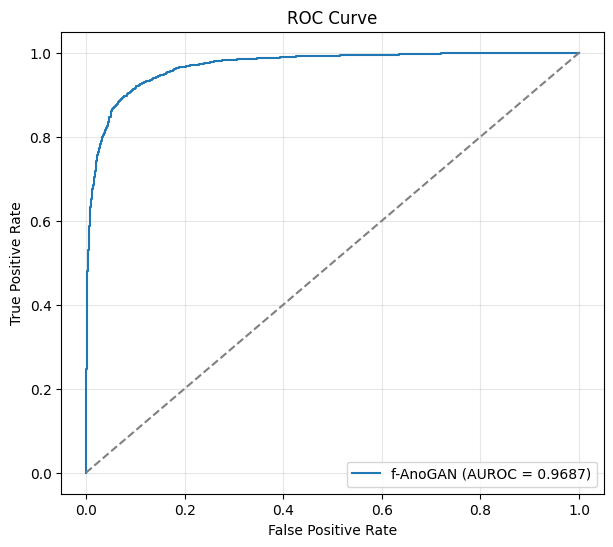

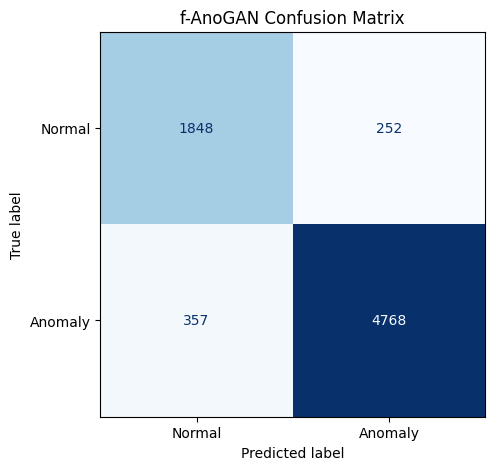


========== Lowest anomaly scores ==========
Score: 0.022192 | True label: 0 | Path: /content/nssc_dataset/test+train/test/normal/ESP_015897_2655_RED-0052-fv.jpg
Score: 0.023367 | True label: 0 | Path: /content/nssc_dataset/test+train/test/normal/ESP_015897_2655_RED-0052-r180.jpg
Score: 0.026315 | True label: 0 | Path: /content/nssc_dataset/test+train/test/normal/ESP_015897_2655_RED-0052-fh.jpg
Score: 0.028825 | True label: 0 | Path: /content/nssc_dataset/test+train/test/normal/PSP_003703_2035_RED-0075-r180.jpg
Score: 0.028984 | True label: 0 | Path: /content/nssc_dataset/test+train/test/normal/ESP_015897_2655_RED-0035-r270.jpg

========== Highest anomaly scores ==========
Score: 0.431962 | True label: 1 | Path: /content/nssc_dataset/test+train/test/anomaly_real/PSP_002776_2025_RED-0100-fh.jpg
Score: 0.383509 | True label: 1 | Path: /content/nssc_dataset/test+train/test/anomaly_real/ESP_019263_2650_RED-0092.jpg
Score: 0.363343 | True label: 1 | Path: /content/nssc_dataset/test+train/te

In [8]:
# Run this AFTER encoder training.
# It uses only normal training images to choose the threshold.
# Test labels are used only at the final evaluation step.

import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# -------------------------
# Threshold settings
# -------------------------
CALIBRATION_FRACTION = 0.15
THRESHOLD_QUANTILE = 0.90
# 0.99 means approximately the highest 1% of normal calibration scores
# are allowed to be predicted as anomalies.


@torch.no_grad()
def get_anomaly_scores(data_loader):
    """
    Returns:
        scores: anomaly score for each image
        labels: 0=normal, 1=anomaly
        paths: image file paths

    score =
        LAMBDA_REC * reconstruction L1 loss
        + (1 - LAMBDA_REC) * discriminator feature L1 loss
    """
    generator.eval()
    discriminator.eval()
    encoder.eval()

    all_scores = []
    all_labels = []
    all_paths = []

    for images, labels, paths in tqdm(data_loader, desc="Calculating anomaly scores"):
        images = images.to(device)

        # Image -> latent code -> reconstructed image
        z = encoder(images)
        reconstructed_images = generator(z)

        # Reconstruction loss for every image
        reconstruction_loss = torch.mean(
            torch.abs(images - reconstructed_images),
            dim=(1, 2, 3),
        )

        # Discriminator feature loss for every image
        _, real_features = discriminator(images, return_features=True)
        _, reconstructed_features = discriminator(
            reconstructed_images,
            return_features=True,
        )

        feature_loss = torch.mean(
            torch.abs(real_features - reconstructed_features),
            dim=(1, 2, 3),
        )

        # Final f-AnoGAN anomaly score
        anomaly_score = (
            LAMBDA_REC * reconstruction_loss
            + (1 - LAMBDA_REC) * feature_loss
        )

        all_scores.extend(anomaly_score.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_paths.extend(paths)

    return (
        np.array(all_scores),
        np.array(all_labels),
        all_paths,
    )
# ============================================================
# Feature-error visualization utilities
# ============================================================

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np


@torch.no_grad()
def get_feature_error_maps(data_loader, max_images=12):
    """
    Calculate spatial discriminator feature-error maps.

    For each image:
        image
            -> Encoder
            -> Generator
            -> reconstruction

        Then compare:
            D(real image)
            D(reconstructed image)

    Returns:
        images              : original images
        reconstructed_images: reconstructed images
        feature_error_maps  : spatial feature-error maps
        scores              : scalar feature errors
        labels              : image labels
        paths               : image paths
    """

    generator.eval()
    discriminator.eval()
    encoder.eval()

    images_list = []
    reconstructed_list = []
    feature_maps = []
    feature_scores = []
    labels_list = []
    paths_list = []

    collected = 0

    for images, labels, paths in data_loader:

        if collected >= max_images:
            break

        images = images.to(device)

        # ----------------------------------------------------
        # 1. Image -> latent vector
        # ----------------------------------------------------
        z = encoder(images)

        # ----------------------------------------------------
        # 2. Latent vector -> reconstruction
        # ----------------------------------------------------
        reconstructed_images = generator(z)

        # ----------------------------------------------------
        # 3. Discriminator feature maps
        # ----------------------------------------------------
        _, real_features = discriminator(
            images,
            return_features=True,
        )

        _, reconstructed_features = discriminator(
            reconstructed_images,
            return_features=True,
        )

        # ----------------------------------------------------
        # 4. Spatial feature discrepancy
        # ----------------------------------------------------
        feature_difference = torch.abs(
            real_features - reconstructed_features
        )

        # Average across feature channels.
        #
        # Shape:
        #     [B, C, H, W]
        #
        # becomes:
        #     [B, H, W]
        spatial_error = torch.mean(
            feature_difference,
            dim=1,
        )

        # Scalar feature error used by f-AnoGAN
        scalar_feature_error = torch.mean(
            feature_difference,
            dim=(1, 2, 3),
        )

        batch_size = images.size(0)

        remaining = max_images - collected
        take = min(batch_size, remaining)

        images_list.append(
            images[:take].cpu()
        )

        reconstructed_list.append(
            reconstructed_images[:take].cpu()
        )

        feature_maps.append(
            spatial_error[:take].cpu()
        )

        feature_scores.append(
            scalar_feature_error[:take].cpu()
        )

        labels_list.extend(
            labels[:take].cpu().numpy()
        )

        paths_list.extend(
            paths[:take]
        )

        collected += take

    return (
        torch.cat(images_list),
        torch.cat(reconstructed_list),
        torch.cat(feature_maps),
        torch.cat(feature_scores).numpy(),
        np.array(labels_list),
        paths_list,
    )

# ---------------------------------------------------
# 1. Select threshold from NORMAL TRAINING IMAGES ONLY
# ---------------------------------------------------
# This does not access test labels or test images.

number_of_calibration_images = int(
    len(train_dataset) * CALIBRATION_FRACTION
)

random_generator = torch.Generator().manual_seed(42)

calibration_indices = torch.randperm(
    len(train_dataset),
    generator=random_generator,
)[:number_of_calibration_images]

calibration_dataset = Subset(
    train_dataset,
    calibration_indices.tolist(),
)

calibration_loader = DataLoader(
    calibration_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

calibration_scores, _, _ = get_anomaly_scores(calibration_loader)

# Threshold is based entirely on normal training-image scores.
anomaly_threshold = np.quantile(
    calibration_scores,
    THRESHOLD_QUANTILE,
)

print(f"\nCalibration normal images: {len(calibration_dataset)}")
print(f"Threshold quantile: {THRESHOLD_QUANTILE}")
print(f"Selected anomaly threshold: {anomaly_threshold:.6f}")


# -------------------------------------
# 2. Calculate scores for TEST images
# -------------------------------------
test_scores, test_labels, test_paths = get_anomaly_scores(test_loader)

# Score >= threshold means anomaly.
test_predictions = (
    test_scores >= anomaly_threshold
).astype(int)


# -------------------------------------
# 3. Final evaluation using TEST labels
# -------------------------------------
accuracy = accuracy_score(test_labels, test_predictions)
precision = precision_score(
    test_labels,
    test_predictions,
    zero_division=0,
)
recall = recall_score(
    test_labels,
    test_predictions,
    zero_division=0,
)
f1 = f1_score(
    test_labels,
    test_predictions,
    zero_division=0,
)
auroc = roc_auc_score(test_labels, test_scores)

# Area Under the Precision-Recall Curve
auprc = average_precision_score(
    test_labels,
    test_scores,
)

print("\n========== f-AnoGAN Test Results ==========")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 score:  {f1:.4f}")
print(f"AUROC:     {auroc:.4f}")
print(f"AUPRC:     {auprc:.4f}")


# -------------------------
# 4. ROC curve
# -------------------------
false_positive_rate, true_positive_rate, _ = roc_curve(
    test_labels,
    test_scores,
)

plt.figure(figsize=(7, 6))
plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=f"f-AnoGAN (AUROC = {auroc:.4f})",
)
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("roc_curve.png", dpi=200, bbox_inches="tight")
plt.show()


# -------------------------
# 5. Confusion matrix
# -------------------------
confusion = confusion_matrix(
    test_labels,
    test_predictions,
)

display = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=["Normal", "Anomaly"],
)

fig, axis = plt.subplots(figsize=(6, 5))
display.plot(ax=axis, cmap="Blues", colorbar=False)
axis.set_title("f-AnoGAN Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()


# -------------------------
# 6. Print example scores
# -------------------------
sorted_indices = np.argsort(test_scores)

print("\n========== Lowest anomaly scores ==========")
for index in sorted_indices[:5]:
    print(
        f"Score: {test_scores[index]:.6f} | "
        f"True label: {test_labels[index]} | "
        f"Path: {test_paths[index]}"
    )

print("\n========== Highest anomaly scores ==========")
for index in sorted_indices[-5:][::-1]:
    print(
        f"Score: {test_scores[index]:.6f} | "
        f"True label: {test_labels[index]} | "
        f"Path: {test_paths[index]}"
    )


# -------------------------
# 7. Save every test score
# -------------------------
with open("test_anomaly_scores.csv", "w", encoding="utf-8") as file:
    file.write("image_path,true_label,anomaly_score,prediction\n")

    for path, label, score, prediction in zip(
        test_paths,
        test_labels,
        test_scores,
        test_predictions,
    ):
        file.write(
            f'"{path}",{label},{score:.8f},{prediction}\n'
        )

print("\nSaved:")
print("- roc_curve.png")
print("- confusion_matrix.png")
print("- test_anomaly_scores.csv")

In [9]:
# ============================================================
# Feature-error heatmaps
# ============================================================

def denormalize_image(image):
    """
    Convert an image from [-1, 1] back to [0, 1].
    """

    image = image.clone()

    image = (image + 1.0) / 2.0

    return torch.clamp(image, 0.0, 1.0)


def plot_feature_error_heatmaps(
    images,
    reconstructed_images,
    feature_error_maps,
    feature_scores,
    labels,
    paths,
    num_images=8,
):
    """
    Plot:

        Original
        Reconstruction
        Feature-error heatmap
        Overlay

    for several examples.
    """

    num_images = min(
        num_images,
        len(images),
    )

    for index in range(num_images):

        original = denormalize_image(
            images[index]
        )

        reconstruction = denormalize_image(
            reconstructed_images[index]
        )

        feature_error = feature_error_maps[index]

        # ----------------------------------------------------
        # Normalize heatmap for visualization only
        # ----------------------------------------------------
        feature_error = (
            feature_error - feature_error.min()
        ) / (
            feature_error.max()
            - feature_error.min()
            + 1e-8
        )

        # Convert CHW -> HWC
        original_np = (
            original.permute(1, 2, 0)
            .numpy()
        )

        reconstruction_np = (
            reconstruction.permute(1, 2, 0)
            .numpy()
        )

        heatmap_np = feature_error.numpy()

        # ----------------------------------------------------
        # Resize feature map to image resolution
        # ----------------------------------------------------
        heatmap_tensor = feature_error.unsqueeze(0).unsqueeze(0)

        heatmap_tensor = F.interpolate(
            heatmap_tensor,
            size=original.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        heatmap_np = (
            heatmap_tensor.squeeze()
            .numpy()
        )

        # ----------------------------------------------------
        # Plot
        # ----------------------------------------------------
        fig, axes = plt.subplots(
            1,
            4,
            figsize=(16, 4),
        )

        axes[0].imshow(original_np)
        axes[0].set_title(
            f"Original\nLabel = {labels[index]}"
        )

        axes[1].imshow(reconstruction_np)
        axes[1].set_title("Reconstruction")

        axes[2].imshow(
            heatmap_np,
            cmap="inferno",
        )

        axes[2].set_title(
            f"Feature Error\n"
            f"Score = {feature_scores[index]:.4f}"
        )

        axes[3].imshow(original_np)
        axes[3].imshow(
            heatmap_np,
            cmap="inferno",
            alpha=0.45,
        )

        axes[3].set_title("Feature Error Overlay")

        for axis in axes:
            axis.axis("off")

        fig.suptitle(
            f"f-AnoGAN Feature Discrepancy\n"
            f"{paths[index]}",
            fontsize=12,
        )

        plt.tight_layout()
        plt.show()

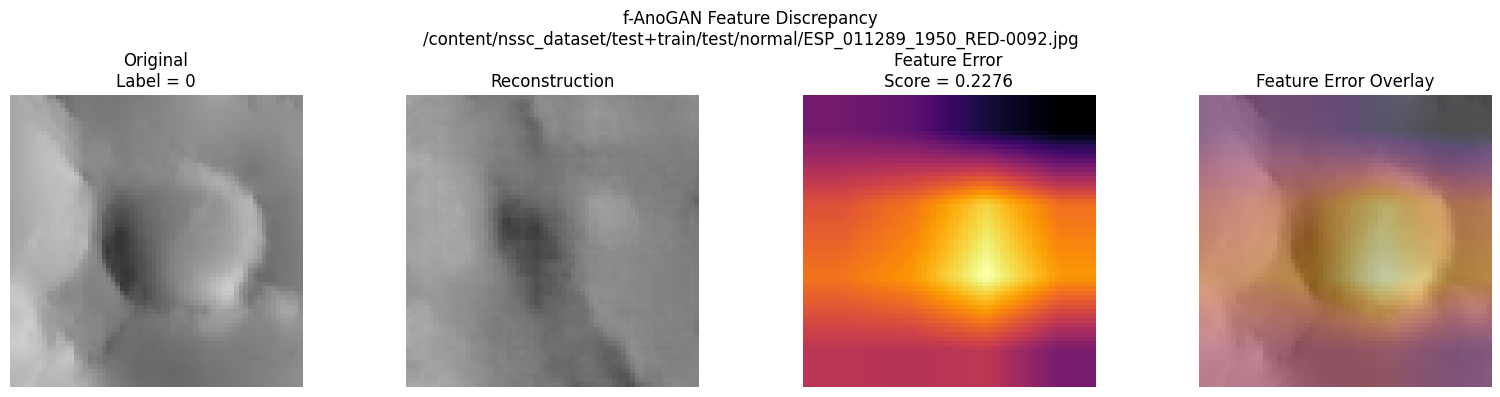

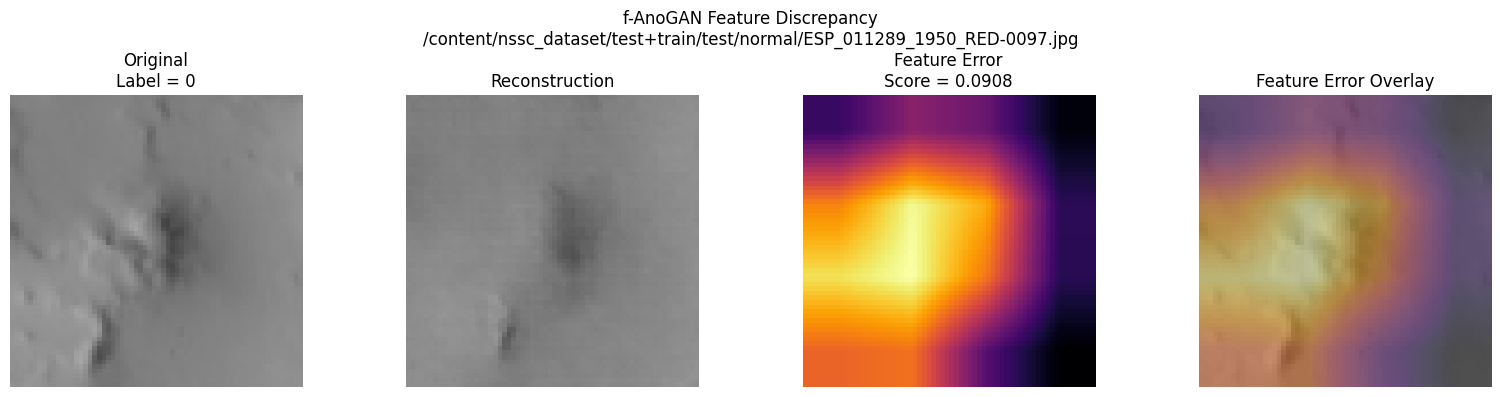

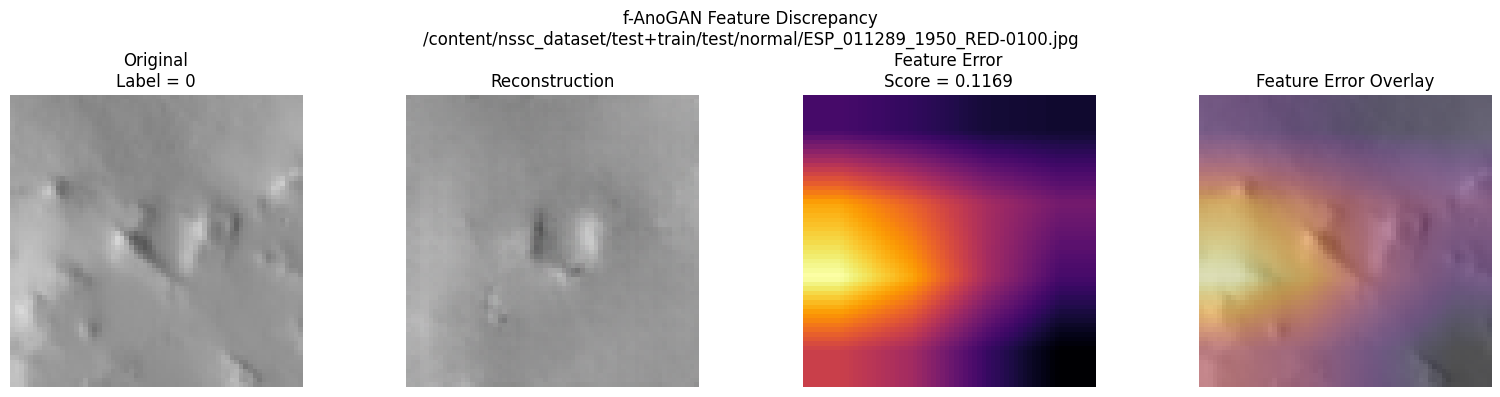

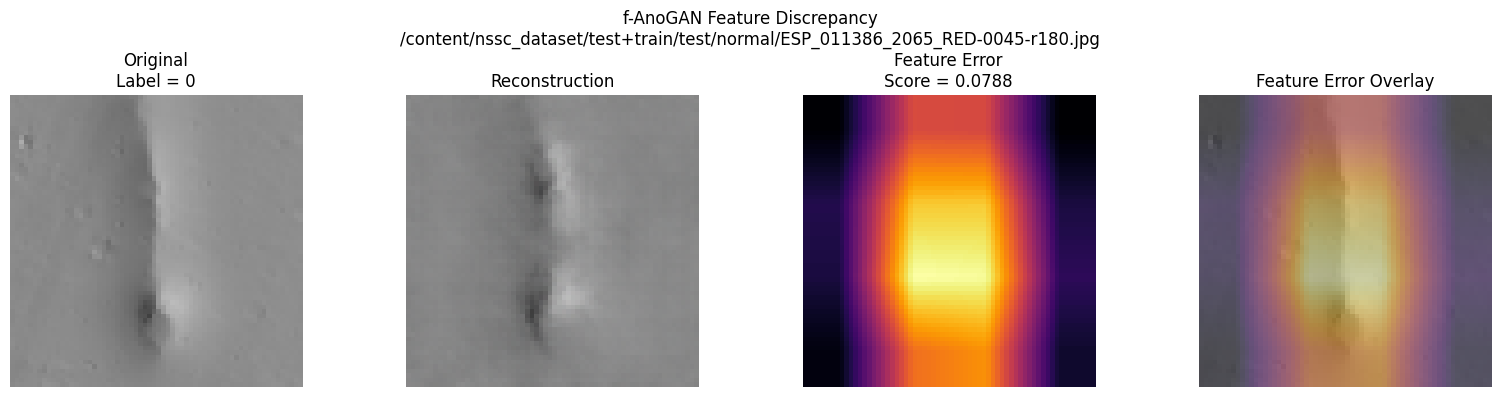

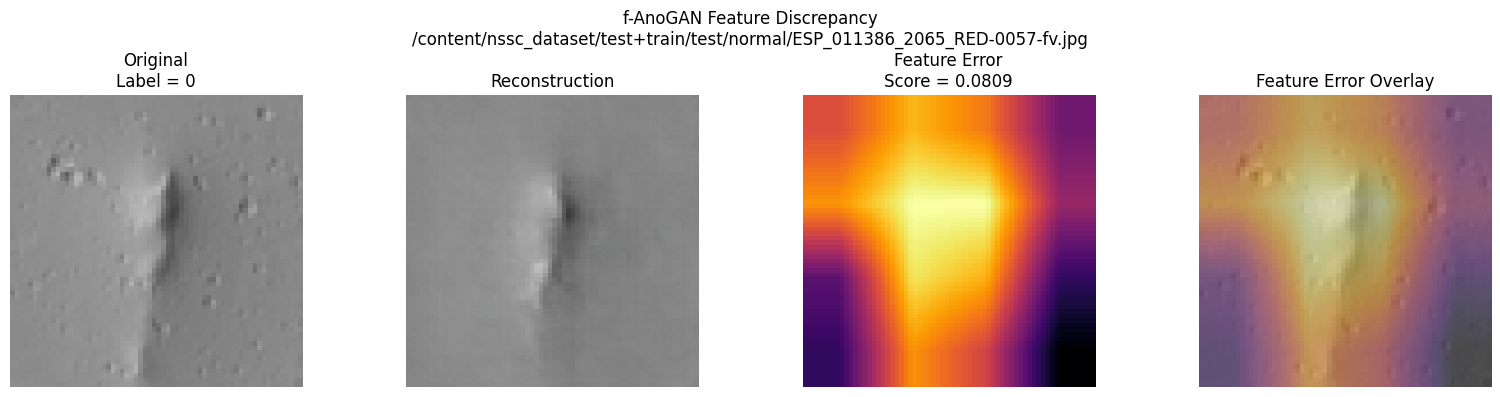

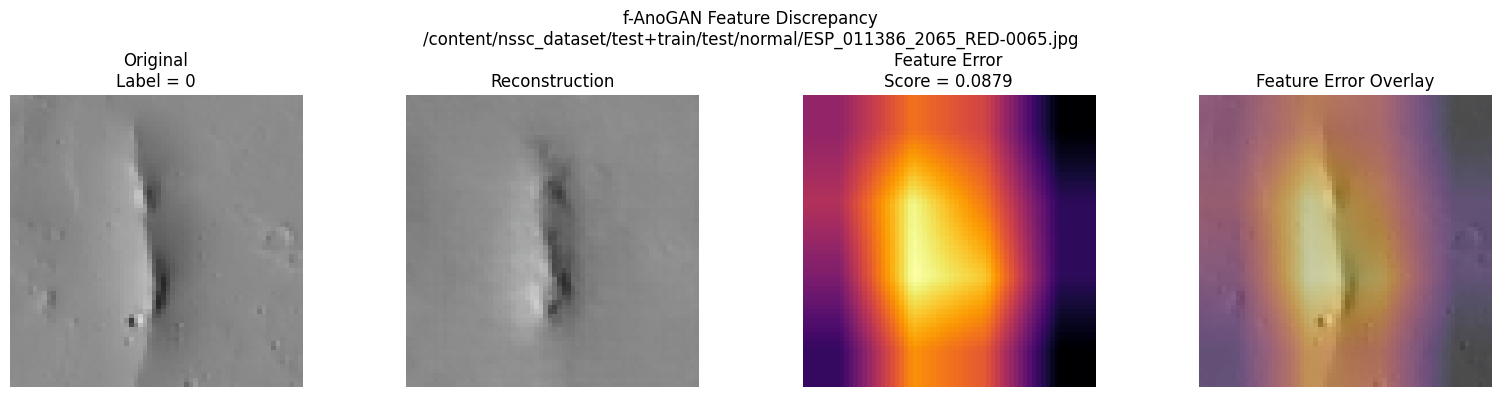

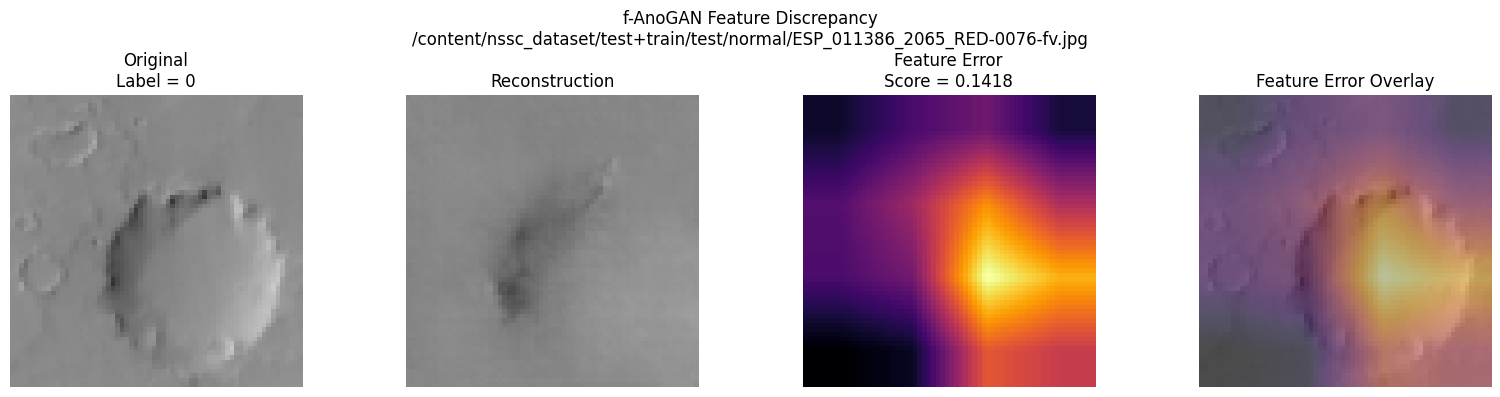

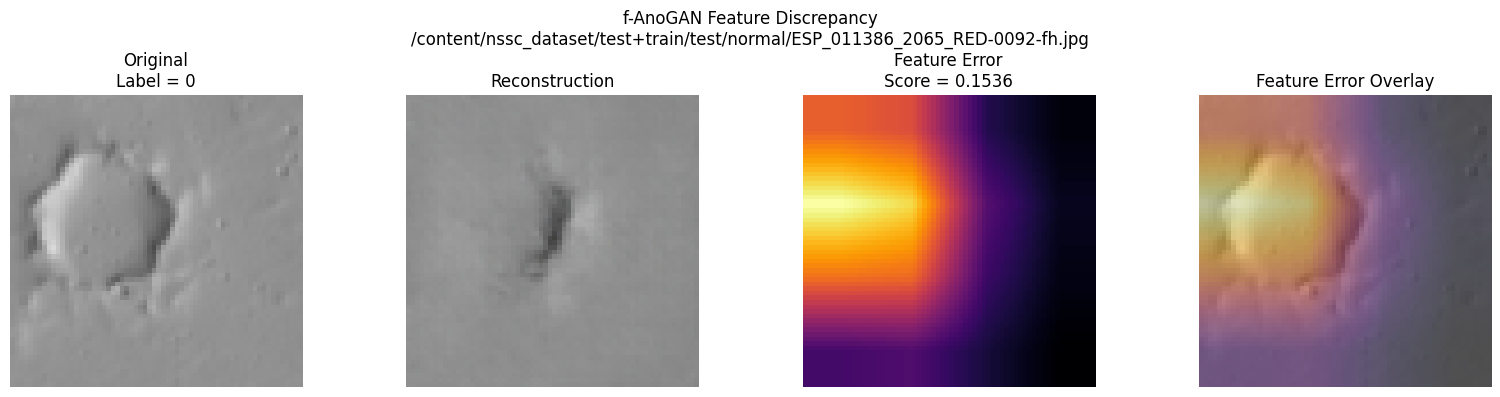

In [10]:
# ============================================================
# Generate feature-error heatmaps for test images
# ============================================================

heatmap_images, \
heatmap_reconstructions, \
heatmap_maps, \
heatmap_scores, \
heatmap_labels, \
heatmap_paths = get_feature_error_maps(
    test_loader,
    max_images=8,
)

plot_feature_error_heatmaps(
    heatmap_images,
    heatmap_reconstructions,
    heatmap_maps,
    heatmap_scores,
    heatmap_labels,
    heatmap_paths,
    num_images=8,
)